In [ ]:
pip install contextily

In [ ]:
# packages
from google.colab import files
import io
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx

In [ ]:
## Read in SOPP Dataset
file_path = '/content/drive/MyDrive/case_study/tn_nashville_2020_04_01.csv'
sopp_df = pd.read_csv(file_path)

/tmp/ipykernel_304/3313685062.py:3: DtypeWarning: Columns (6,8,15,16,17,22,23,24,25,29,30,31,32,33,35,36,37,38,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  sopp_df = pd.read_csv(file_path)


In [ ]:
## Read in 2009 - 2019 Crash Dataset and Merge Each Year's Crash Dataset with Person Dataset
# 2009
file_path = '/content/drive/MyDrive/case_study/ACCIDENT9.CSV'
acc9_df = pd.read_csv(file_path)

acc9_tn_df = acc9_df[acc9_df['STATE'] == 47]
acc9_nash_df = acc9_tn_df[acc9_tn_df['CITY'] == 1760]

# 2010
file_path = '/content/drive/MyDrive/case_study/ACCIDENT10.CSV'
acc10_df = pd.read_csv(file_path)

acc10_tn_df = acc10_df[acc10_df['STATE'] == 47]
acc10_nash_df = acc10_tn_df[acc10_tn_df['CITY'] == 1760]

# 2011
file_path = '/content/drive/MyDrive/case_study/ACCIDENT11.CSV'
acc11_df = pd.read_csv(file_path)

acc11_tn_df = acc11_df[acc11_df['STATE'] == 47]
acc11_nash_df = acc11_tn_df[acc11_tn_df['CITY'] == 1760]

# 2012
file_path = '/content/drive/MyDrive/case_study/ACCIDENT12.csv'
acc12_df = pd.read_csv(file_path)

acc12_tn_df = acc12_df[acc12_df['STATE'] == 47]
acc12_nash_df = acc12_tn_df[acc12_tn_df['CITY'] == 1760]

# 2013
file_path = '/content/drive/MyDrive/case_study/ACCIDENT13.csv'
acc13_df = pd.read_csv(file_path)

acc13_tn_df = acc13_df[acc13_df['STATE'] == 47]
acc13_nash_df = acc13_tn_df[acc13_tn_df['CITY'] == 1760]

# 2014
file_path = '/content/drive/MyDrive/case_study/ACCIDENT14.csv'
acc14_df = pd.read_csv(file_path)

acc14_tn_df = acc14_df[acc14_df['STATE'] == 47]
acc14_nash_df = acc14_tn_df[acc14_tn_df['CITY'] == 1760]

# 2015
file_path = '/content/drive/MyDrive/case_study/accident15.csv'
acc15_df = pd.read_csv(file_path)

acc15_tn_df = acc15_df[acc15_df['STATE'] == 47]
acc15_nash_df = acc15_tn_df[acc15_tn_df['CITY'] == 1760]

# 2016
file_path = '/content/drive/MyDrive/case_study/accident16.CSV'
acc16_df = pd.read_csv(file_path)

acc16_tn_df = acc16_df[acc16_df['STATE'] == 47]
acc16_nash_df = acc16_tn_df[acc16_tn_df['CITY'] == 1760]

# 2017
file_path = '/content/drive/MyDrive/case_study/accident17.CSV'
acc17_df = pd.read_csv(file_path)

acc17_tn_df = acc17_df[acc17_df['STATE'] == 47]
acc17_nash_df = acc17_tn_df[acc17_tn_df['CITY'] == 1760]

# 2018
file_path = '/content/drive/MyDrive/case_study/accident18.csv'
acc18_df = pd.read_csv(file_path)

acc18_tn_df = acc18_df[acc18_df['STATE'] == 47]
acc18_nash_df = acc18_tn_df[acc18_tn_df['CITY'] == 1760]

# 2019
file_path = '/content/drive/MyDrive/case_study/accident19.CSV'
acc19_df = pd.read_csv(file_path, encoding = 'latin-1')

acc19_tn_df = acc19_df[acc19_df['STATE'] == 47]
acc19_nash_df = acc19_tn_df[acc19_tn_df['CITY'] == 1760]

/tmp/ipython-input-509/500542239.py:60: DtypeWarning: Columns (40,42) have mixed types. Specify dtype option on import or set low_memory=False.
  acc17_df = pd.read_csv(file_path)
/tmp/ipython-input-509/500542239.py:74: DtypeWarning: Columns (40,42) have mixed types. Specify dtype option on import or set low_memory=False.
  acc19_df = pd.read_csv(file_path, encoding = 'latin-1')


In [ ]:
## Merge Crash Datasets
acc_nash_df = pd.concat([acc9_nash_df, acc10_nash_df, acc11_nash_df, acc12_nash_df,
                               acc13_nash_df, acc14_nash_df, acc15_nash_df, acc16_nash_df,
                               acc17_nash_df, acc18_nash_df, acc19_nash_df], ignore_index=True)

In [ ]:
# Create lists of columns names for each year and find the ones that are present for all
list9 = acc9_nash_df.columns.tolist()
list10 = acc10_nash_df.columns.tolist()
list11 = acc11_nash_df.columns.tolist()
list12 = acc12_nash_df.columns.tolist()
list13 = acc13_nash_df.columns.tolist()
list14 = acc14_nash_df.columns.tolist()
list15 = acc15_nash_df.columns.tolist()
list16 = acc16_nash_df.columns.tolist()
list17 = acc17_nash_df.columns.tolist()
list18 = acc18_nash_df.columns.tolist()
list19 = acc19_nash_df.columns.tolist()

commons = set(list9).intersection(list10, list11, list12, list13, list14, list15, list16, list17, list18, list19)
columns = list(commons)

In [ ]:
## Final Dataset
# remove any columns that aren't present for every year
df = acc_nash_df[columns]

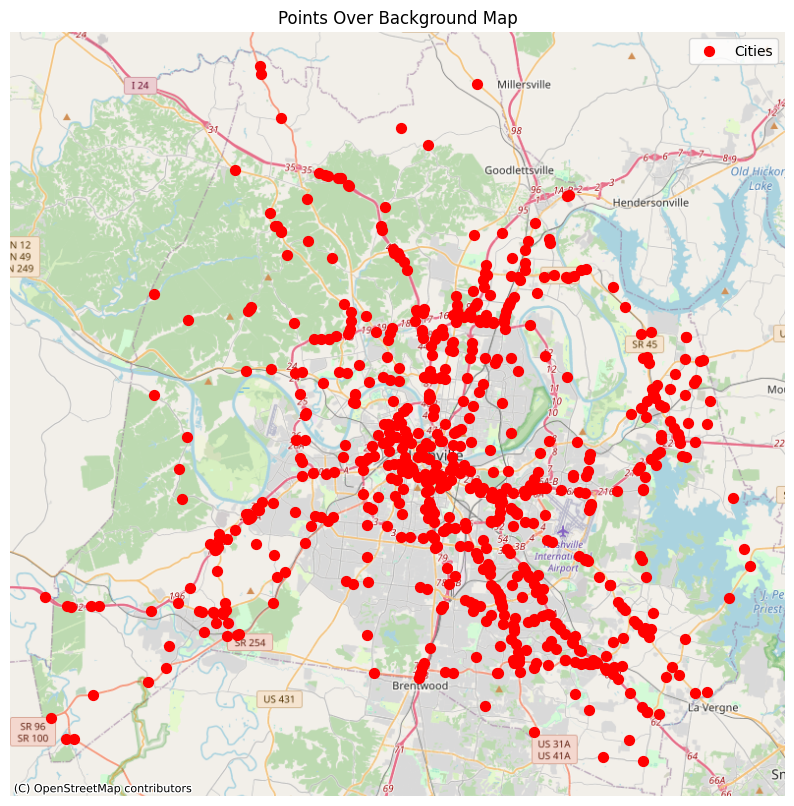

In [ ]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.LONGITUD, df.LATITUDE),
    crs="EPSG:4326")

gdf_web_mercator = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_web_mercator.plot(ax=ax, marker='o', color='red', markersize=50, label='Crashes')

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Points Over Background Map")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


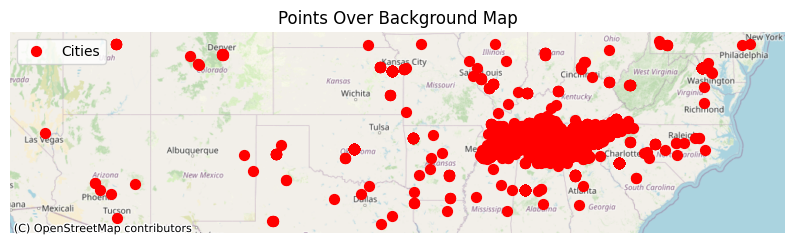

In [ ]:
gdf = gpd.GeoDataFrame(
    sopp_df,
    geometry=gpd.points_from_xy(sopp_df.lng, sopp_df.lat),
    crs="EPSG:4326")

gdf_web_mercator = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_web_mercator.plot(ax=ax, marker='o', color='red', markersize=50, label='Police Stops')

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Points Over Background Map")
plt.legend()
plt.show()

In [ ]:
# read in shape file to fix sopp data
file_path = '/content/drive/MyDrive/case_study/kx-nashville-tennessee-parcels-SHP/nashville-tennessee-parcels.shp'
parcels = gpd.read_file(file_path)

In [ ]:
# create sopp data fram in geopandas
sopp = gpd.GeoDataFrame(
    sopp_df,
    geometry=gpd.points_from_xy(sopp_df.lng, sopp_df.lat),
    crs="EPSG:4326"
)

In [ ]:
# ensure crs are the same for both files
parcels = parcels.to_crs(sopp.crs)
print(sopp.crs)
print(parcels.crs)

EPSG:4326
EPSG:4326


In [ ]:
# join them
sopp_within_parcels = gpd.sjoin(
    sopp,
    parcels,
    how="inner",
    predicate="within"
)

In [ ]:
# only include columns from sopp data
sopp_df = sopp_within_parcels[sopp.columns]

In [ ]:
sopp_df.to_csv('sopp_df.csv')

In [ ]:
files.download('sopp_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


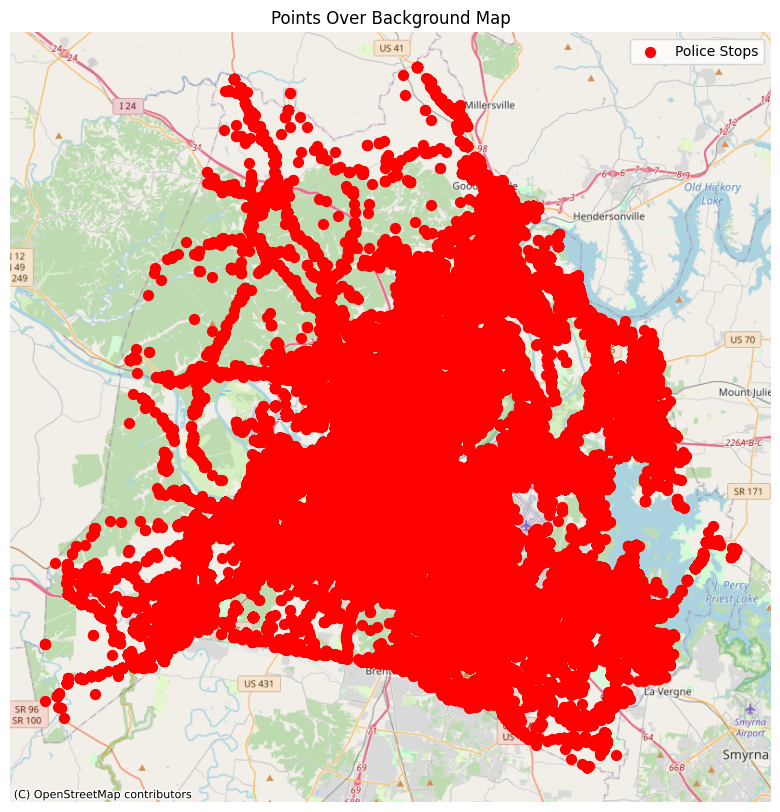

In [ ]:
gdf = gpd.GeoDataFrame(
    sopp_df,
    geometry=gpd.points_from_xy(sopp_df.lng, sopp_df.lat),
    crs="EPSG:4326")

gdf_web_mercator = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_web_mercator.plot(ax=ax, marker='o', color='red', markersize=50, label='Police Stops')

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Points Over Background Map")
plt.legend()
plt.show()

In [ ]:
sopp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3092351 entries, 0 to 3092350
Data columns (total 42 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   raw_row_number                  object 
 1   date                            object 
 2   time                            object 
 3   location                        object 
 4   lat                             float64
 5   lng                             float64
 6   precinct                        object 
 7   reporting_area                  float64
 8   zone                            object 
 9   subject_age                     float64
 10  subject_race                    object 
 11  subject_sex                     object 
 12  officer_id_hash                 object 
 13  type                            object 
 14  violation                       object 
 15  arrest_made                     object 
 16  citation_issued                 object 
 17  warning_issued             